In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import requests
import time

In [3]:
df = pd.read_excel("ds.xlsx")

In [4]:
# find all missing datas in data frame
nan_rows = df[df.isna().any(axis=1)]
nan_rows

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
19,1020,Kimia,M,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16,187.17,2994.72,4,Cash,Web,Yes,1,5
39,1040,Amir,F,65.0,Tehran,Tehran,2021-11-02,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2


In [5]:
# find all outlayers in numeric datas and delete them

numeric_df = df.select_dtypes(include=['number'])
numeric_cols = numeric_df.columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan



In [6]:
nan_rows = df[df.isna().any(axis=1)]
nan_rows

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
8,1009.0,Kimia,M,61.0,Karaj,Alborz,2021-05-14,Silver,34.0,341.63,NaN,232.0,Card,Web,No,8.0,2.0
9,1010.0,Arash,F,NaN,Karaj,Alborz,2022-06-25,Silver,19.0,381.13,7241.47,276.0,Online Wallet,Android,No,7.0,1.0
11,1012.0,Arash,F,51.0,Mashhad,Khorasan,2023-07-22,Gold,27.0,434.50,NaN,224.0,Online Wallet,iPhone,Yes,3.0,2.0
19,1020.0,Kimia,M,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16.0,187.17,2994.72,4.0,Cash,Web,Yes,1.0,5.0
29,1030.0,Sina,M,60.0,Mashhad,Khorasan,2025-03-07,VIP,26.0,156.89,NaN,340.0,Cash,Web,Yes,4.0,4.0
39,1040.0,Amir,F,65.0,Tehran,Tehran,2021-11-02,Bronze,34.0,37.66,NaN,126.0,Card,Android,Yes,3.0,2.0
43,1044.0,Mina,M,64.0,Shiraz,Fars,2024-07-27,Gold,33.0,434.98,NaN,165.0,Card,Android,No,7.0,2.0
56,1057.0,Maryam,M,58.0,Ahvaz,Khuzestan,2024-06-11,Bronze,31.0,436.54,NaN,82.0,Cash,iPhone,No,4.0,4.0


In [7]:
corr_matrix = numeric_df.corr()


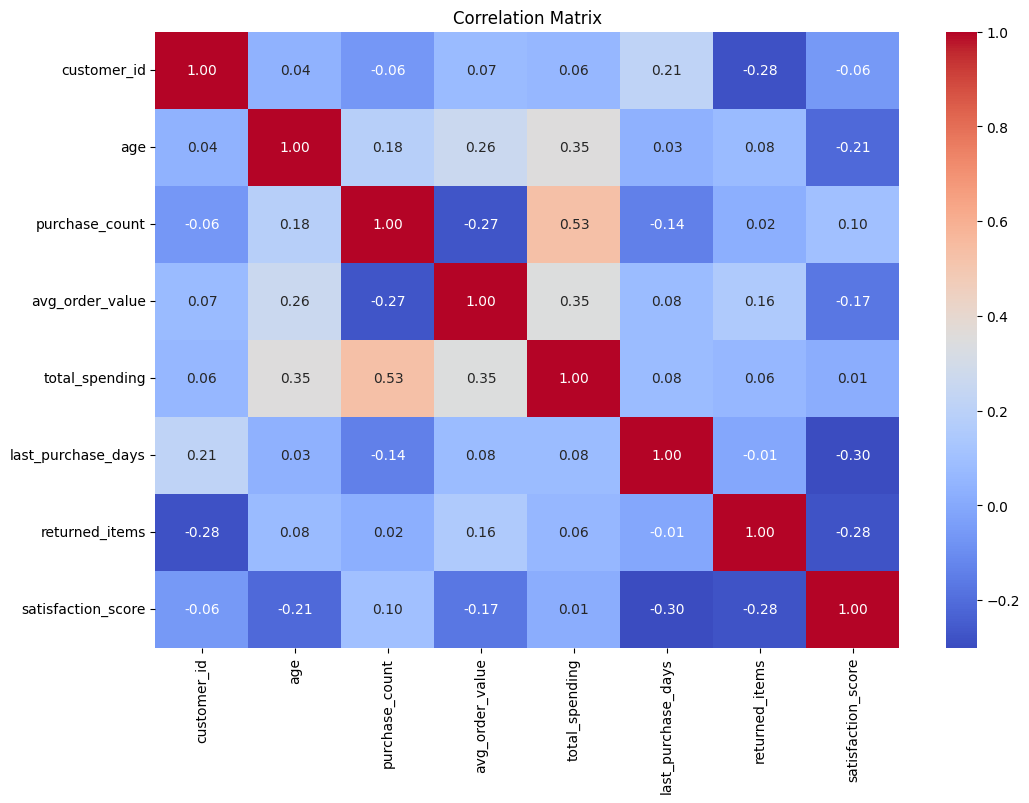

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

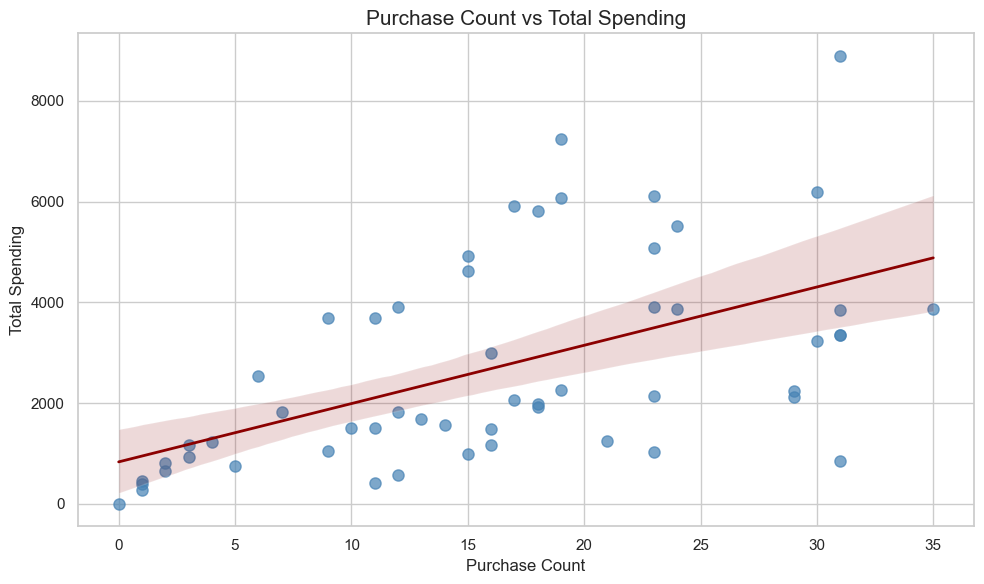

In [9]:
relationship_df = (
    df[["purchase_count", "total_spending"]]
    .dropna()
    .copy()
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=relationship_df,
    x="purchase_count",
    y="total_spending",
    ci=95,
    scatter_kws={
        "alpha": 0.7,
        "s": 65,
        "color": "steelblue"
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    }
)

plt.title("Purchase Count vs Total Spending", fontsize=15)
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()


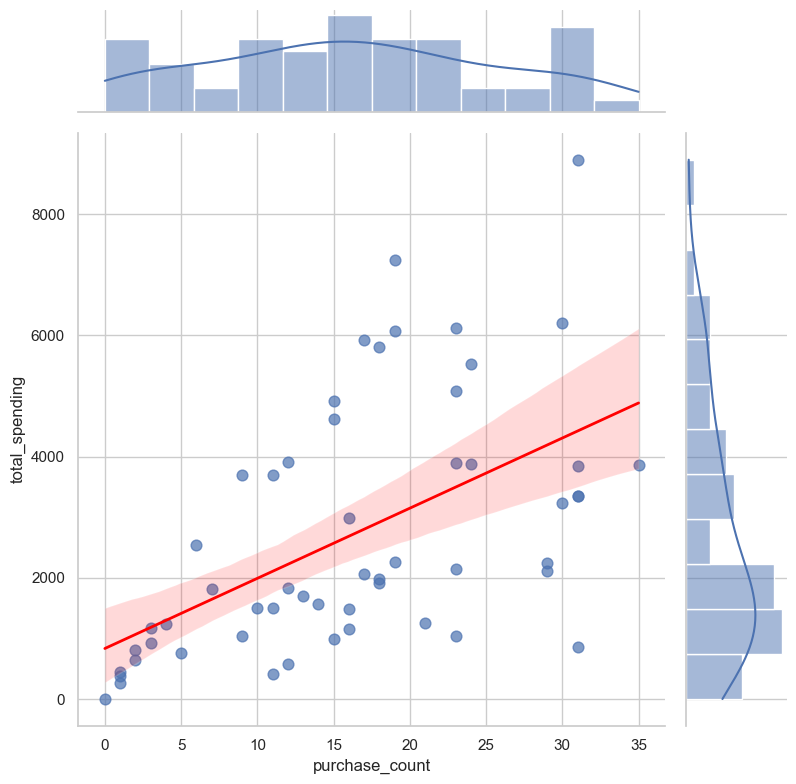

In [ ]:
g = sns.jointplot(
    data=relationship_df,
    x="purchase_count",
    y="total_spending",
    kind="reg",
    height=8,
    scatter_kws={
        "alpha": 0.7,
        "s": 60
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    marginal_kws={
        "bins": 12
    }
)

g.fig.suptitle(
    "",
    y=1.02,
    fontsize=15
)

plt.show()


In [10]:
from scipy.stats import pearsonr, spearmanr

x = relationship_df["purchase_count"]
y = relationship_df["total_spending"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r  = {pearson_r:.3f}")
print(f"Pearson p  = {pearson_p:.5f}")

print(f"Spearman r = {spearman_r:.3f}")
print(f"Spearman p = {spearman_p:.5f}")


Pearson r  = 0.546
Pearson p  = 0.00002
Spearman r = 0.627
Spearman p = 0.00000


In [11]:
check_df = (
    df[
        [
            "purchase_count",
            "avg_order_value",
            "total_spending"
        ]
    ]
    .dropna()
    .copy()
)

check_df["estimated_total_spending"] = (
    check_df["purchase_count"]
    * check_df["avg_order_value"]
)

check_df["difference"] = (
    check_df["total_spending"]
    - check_df["estimated_total_spending"]
)

print(
    check_df[
        [
            "total_spending",
            "estimated_total_spending",
            "difference"
        ]
    ].head(10)
)


    total_spending  estimated_total_spending    difference
0          2066.01                   2066.01  0.000000e+00
1          3917.64                   3917.64 -4.547474e-13
2          1248.66                   1248.66  0.000000e+00
3          6121.45                   6121.45  0.000000e+00
4          3899.42                   3899.42  4.547474e-13
5          3868.55                   3868.55  0.000000e+00
6          2237.35                   2237.35 -4.547474e-13
7          1168.74                   1168.74  0.000000e+00
9          7241.47                   7241.47  0.000000e+00
10         2264.04                   2264.04  0.000000e+00


In [12]:
mask = (
    df["total_spending"].isna()
    & df["purchase_count"].notna()
    & df["avg_order_value"].notna()
)
df.loc[mask, "total_spending"] = (
    df.loc[mask, "purchase_count"] * df.loc[mask, "avg_order_value"]
)

In [13]:
nan_rows = df[df.isna().any(axis=1)]
nan_rows

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010.0,Arash,F,NaN,Karaj,Alborz,2022-06-25,Silver,19.0,381.13,7241.47,276.0,Online Wallet,Android,No,7.0,1.0
19,1020.0,Kimia,M,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16.0,187.17,2994.72,4.0,Cash,Web,Yes,1.0,5.0


In [14]:

# Select input features for predicting age
features = [
    "total_spending",
    "avg_order_value",
    "purchase_count",
    "satisfaction_score"
]

# Training data: rows where age is available
train_df = df[df["age"].notna()][features + ["age"]].dropna()

# Prediction data: rows where age is missing but features are available
pred_df = df[df["age"].isna()][features].dropna()

# Initialize the model
model = RandomForestRegressor(random_state=42, n_estimators=200)


In [15]:
# Train the model
X_train = train_df[features]
y_train = train_df["age"]
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:

predicted_ages = model.predict(pred_df)

In [17]:
predicted_ages

array([54.88 , 29.485])

In [18]:
df.loc[pred_df.index, "age"] = predicted_ages


In [19]:
df["age"] = df["age"].round().astype("Int64")


In [20]:
nan_rows = df[df.isna().any(axis=1)]
nan_rows

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [21]:
df

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001.0,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17.0,121.53,2066.01,16.0,Card,Android,Yes,3.0,5.0
1,1002.0,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12.0,326.47,3917.64,3.0,Card,Web,No,5.0,3.0
2,1003.0,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21.0,59.46,1248.66,22.0,Online Wallet,iPhone,Yes,6.0,1.0
3,1004.0,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23.0,266.15,6121.45,40.0,Card,Android,No,4.0,4.0
4,1005.0,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23.0,169.54,3899.42,273.0,Online Wallet,Android,Yes,7.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,1057.0,Maryam,M,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31.0,436.54,13532.74,82.0,Cash,iPhone,No,4.0,4.0
57,1058.0,Amir,F,47,Tehran,Tehran,2024-09-27,Bronze,5.0,151.81,759.05,336.0,Online Wallet,iPhone,No,0.0,2.0
58,1059.0,Ali,F,57,Isfahan,Isfahan,2023-09-05,Gold,31.0,287.05,8898.55,224.0,Online Wallet,iPhone,Yes,0.0,5.0
59,1060.0,Ali,M,63,Tabriz,East Azerbaijan,2021-04-27,Bronze,10.0,150.18,1501.80,236.0,Card,Web,Yes,7.0,3.0


In [22]:
# Show all rows that belong to duplicate groups
all_duplicates = df[df.duplicated(keep=False)]
all_duplicates


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
13,1014.0,Reza,M,35,Tabriz,East Azerbaijan,2022-08-26,VIP,31.0,108.19,3353.89,97.0,Card,Android,No,5.0,4.0
60,1014.0,Reza,M,35,Tabriz,East Azerbaijan,2022-08-26,VIP,31.0,108.19,3353.89,97.0,Card,Android,No,5.0,4.0


In [23]:
# Remove duplicated rows
df = df.drop_duplicates()

In [24]:
all_duplicates = df[df.duplicated(keep=False)]
all_duplicates


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [25]:
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001.0,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17.0,121.53,2066.01,16.0,Card,Android,Yes,3.0,5.0
1,1002.0,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12.0,326.47,3917.64,3.0,Card,Web,No,5.0,3.0
2,1003.0,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21.0,59.46,1248.66,22.0,Online Wallet,iPhone,Yes,6.0,1.0
3,1004.0,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23.0,266.15,6121.45,40.0,Card,Android,No,4.0,4.0
4,1005.0,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23.0,169.54,3899.42,273.0,Online Wallet,Android,Yes,7.0,4.0


In [26]:
df.dtypes

customer_id           float64
first_name             object
gender                 object
age                     Int64
city                   object
province               object
signup_date            object
membership_tier        object
purchase_count        float64
avg_order_value       float64
total_spending        float64
last_purchase_days    float64
payment_method         object
device                 object
discount_used          object
returned_items        float64
satisfaction_score    float64
dtype: object

In [27]:
df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce").astype("Int64").astype("string")


C:\Users\sina\AppData\Local\Temp\ipykernel_39424\3081247425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce").astype("Int64").astype("string")


In [28]:
df.dtypes


customer_id           string[python]
first_name                    object
gender                        object
age                            Int64
city                          object
province                      object
signup_date                   object
membership_tier               object
purchase_count               float64
avg_order_value              float64
total_spending               float64
last_purchase_days           float64
payment_method                object
device                        object
discount_used                 object
returned_items               float64
satisfaction_score           float64
dtype: object

In [29]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")


C:\Users\sina\AppData\Local\Temp\ipykernel_39424\1193951238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")


In [30]:
df.dtypes


customer_id           string[python]
first_name                    object
gender                        object
age                            Int64
city                          object
province                      object
signup_date           datetime64[ns]
membership_tier               object
purchase_count               float64
avg_order_value              float64
total_spending               float64
last_purchase_days           float64
payment_method                object
device                        object
discount_used                 object
returned_items               float64
satisfaction_score           float64
dtype: object

In [31]:
int_columns = [
    "purchase_count",
    "last_purchase_days",
    "returned_items"
]

for col in int_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").round().astype("Int64")

C:\Users\sina\AppData\Local\Temp\ipykernel_39424\228963666.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce").round().astype("Int64")
C:\Users\sina\AppData\Local\Temp\ipykernel_39424\228963666.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce").round().astype("Int64")
C:\Users\sina\AppData\Local\Temp\ipykernel_39424\228963666.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [32]:
# Standardize discount_used values to 0 and 1
df["discount_used"] = df["discount_used"].replace({
    "Yes": 1,
    "No": 0,
})

# Convert discount_used to nullable integer
df["discount_used"] = pd.to_numeric(df["discount_used"], errors="coerce").astype("Int64")

C:\Users\sina\AppData\Local\Temp\ipykernel_39424\696570448.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["discount_used"] = df["discount_used"].replace({
C:\Users\sina\AppData\Local\Temp\ipykernel_39424\696570448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["discount_used"] = df["discount_used"].replace({
C:\Users\sina\AppData\Local\Temp\ipykernel_39424\696570448.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [33]:
print(df["signup_date"].dtype)


datetime64[ns]


In [34]:
text_columns = [
    "first_name",
    "gender",
    "city",
    "province",
    "membership_tier",
    "payment_method",
    "device"
]

for col in text_columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    df[col] = df[col].apply(lambda x: " ".join(x.split()) if isinstance(x, str) else x)

C:\Users\sina\AppData\Local\Temp\ipykernel_39424\1720174652.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
C:\Users\sina\AppData\Local\Temp\ipykernel_39424\1720174652.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].apply(lambda x: " ".join(x.split()) if isinstance(x, str) else x)


In [35]:
cat_cols = ["gender", "city", "province", "membership_tier", "payment_method", "device"]

# Apply Title Case to standardize naming (e.g., tehran -> Tehran)
for col in cat_cols:
    df[col] = df[col].apply(lambda x: x.title() if isinstance(x, str) else x)

C:\Users\sina\AppData\Local\Temp\ipykernel_39424\1051633282.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].apply(lambda x: x.title() if isinstance(x, str) else x)


In [37]:

def fetch_genders_scalable(df, name_column="first_name", country="IR"):
    """
    Fetch genders for unique names in a dataframe using batch requests to genderize.io.
    """
    # 1. Get unique names to minimize API calls
    unique_names = df[name_column].dropna().unique().tolist()
    
    gender_map = {}
    batch_size = 10  # API allows multiple names in one request (up to 10 names usually)
    
    print(f"Total unique names to process: {len(unique_names)}")

    for i in range(0, len(unique_names), batch_size):
        batch = unique_names[i:i + batch_size]
        
        # Construct the batch URL (e.g., ?name[]=ali&name[]=sara&country_id=IR)
        params = [('name[]', name) for name in batch]
        params.append(('country_id', country))
        
        try:
            response = requests.get("https://api.genderize.io", params=params)
            
            if response.status_code == 200:
                results = response.json()
                for item in results:
                    if item.get("gender"):
                        # Normalize to Title Case (Male/Female)
                        gender_map[item["name"]] = item["gender"].capitalize()
                    else:
                        gender_map[item["name"]] = None
            
            elif response.status_code == 429:
                print("Rate limit reached. Sleeping for 60 seconds...")
                time.sleep(60)
                # Note: In a real scenario, you'd want to retry this batch
            else:
                print(f"Error {response.status_code} for batch starting with {batch[0]}")

        except Exception as e:
            print(f"Request failed: {e}")

        # Small delay to be polite to the API
        time.sleep(0.5)

    # 2. Map the results back to the original dataframe
    df["gender"] = df[name_column].map(gender_map)
    
    return df

In [38]:
df = fetch_genders_scalable(df, name_column="first_name", country="IR")

Total unique names to process: 12


C:\Users\sina\AppData\Local\Temp\ipykernel_39424\2618603174.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"] = df[name_column].map(gender_map)


In [40]:
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,Male,19,Karaj,Alborz,2025-02-19,Vip,17,121.53,2066.01,16,Card,Android,1,3,5.0
1,1002,Sina,Male,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,0,5,3.0
2,1003,Parsa,Male,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,Iphone,1,6,1.0
3,1004,Sina,Male,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,0,4,4.0
4,1005,Kimia,Female,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,1,7,4.0


In [43]:
df.to_excel("cleaned_dataset.xlsx")